# CREDIT GUARD (*AI-powered credit card risk Prediction analysis system*)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
import warnings
warnings.filterwarnings('ignore')
eda_palette = ['#2A9D8F','#264653', '#E76F51','#E9C46A']
sb.set_theme(style='whitegrid')

In [2]:
a = pd.read_csv('../Datasets/Applications_cc.csv')
a

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
438552,6840104,M,N,Y,0,135000.0,Pensioner,Secondary / secondary special,Separated,House / apartment,-22717,365243,1,0,0,0,NaN,1.0
438553,6840222,F,N,N,0,103500.0,Working,Secondary / secondary special,Single / not married,House / apartment,-15939,-3007,1,0,0,0,Laborers,1.0
438554,6841878,F,N,N,0,54000.0,Commercial associate,Higher education,Single / not married,With parents,-8169,-372,1,1,0,0,Sales staff,1.0
438555,6842765,F,N,Y,0,72000.0,Pensioner,Secondary / secondary special,Married,House / apartment,-21673,365243,1,0,0,0,NaN,2.0


In [3]:
b = pd.read_csv('../Datasets/credit_record _cc.csv')
b

,ID,MONTHS_BALANCE,STATUS
0,5001711,0,X
1,5001711,-1,0
2,5001711,-2,0
3,5001711,-3,0
4,5001712,0,C
...,...,...,...
1048570,5150487,-25,C
1048571,5150487,-26,C
1048572,5150487,-27,C
1048573,5150487,-28,C


## Remove duplicate records based on the unique ID from both datasets

In [4]:
a_cleaned = a.drop_duplicates(subset=['ID'],keep='first')
b_cleaned = b.drop_duplicates(subset=['ID'],keep='first')

In [5]:
a_cleaned

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
438552,6840104,M,N,Y,0,135000.0,Pensioner,Secondary / secondary special,Separated,House / apartment,-22717,365243,1,0,0,0,NaN,1.0
438553,6840222,F,N,N,0,103500.0,Working,Secondary / secondary special,Single / not married,House / apartment,-15939,-3007,1,0,0,0,Laborers,1.0
438554,6841878,F,N,N,0,54000.0,Commercial associate,Higher education,Single / not married,With parents,-8169,-372,1,1,0,0,Sales staff,1.0
438555,6842765,F,N,Y,0,72000.0,Pensioner,Secondary / secondary special,Married,House / apartment,-21673,365243,1,0,0,0,NaN,2.0


In [6]:
b_cleaned

,ID,MONTHS_BALANCE,STATUS
0,5001711,0,X
4,5001712,0,C
23,5001713,0,X
45,5001714,0,X
60,5001715,0,X
...,...,...,...
1048494,5150482,-11,C
1048512,5150483,0,X
1048530,5150484,0,C
1048543,5150485,0,0


# Data Cleaning and Merging of Multiple Datasets
* #### Merges the cleaned datasets using ID as the common key with an inner join.
* #### The resulting dataset contains only records with matching IDs present in both datasets.

In [7]:
df = pd.merge(a_cleaned,b_cleaned,on='ID',how='inner')
df

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,MONTHS_BALANCE,STATUS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,0,C
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,0,C
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0,0,C
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0,0,0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0,-22,X
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36452,5149828,M,Y,Y,0,315000.0,Working,Secondary / secondary special,Married,House / apartment,-17348,-2420,1,0,0,0,Managers,2.0,0,5
36453,5149834,F,N,Y,0,157500.0,Commercial associate,Higher education,Married,House / apartment,-12387,-1325,1,0,1,1,Medicine staff,2.0,0,C
36454,5149838,F,N,Y,0,157500.0,Pensioner,Higher education,Married,House / apartment,-12387,-1325,1,0,1,1,Medicine staff,2.0,0,C
36455,5150049,F,N,Y,0,283500.0,Working,Secondary / secondary special,Married,House / apartment,-17958,-655,1,0,0,0,Sales staff,2.0,0,2


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36457 entries, 0 to 36456
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   36457 non-null  int64  
 1   CODE_GENDER          36457 non-null  object 
 2   FLAG_OWN_CAR         36457 non-null  object 
 3   FLAG_OWN_REALTY      36457 non-null  object 
 4   CNT_CHILDREN         36457 non-null  int64  
 5   AMT_INCOME_TOTAL     36457 non-null  float64
 6   NAME_INCOME_TYPE     36457 non-null  object 
 7   NAME_EDUCATION_TYPE  36457 non-null  object 
 8   NAME_FAMILY_STATUS   36457 non-null  object 
 9   NAME_HOUSING_TYPE    36457 non-null  object 
 10  DAYS_BIRTH           36457 non-null  int64  
 11  DAYS_EMPLOYED        36457 non-null  int64  
 12  FLAG_MOBIL           36457 non-null  int64  
 13  FLAG_WORK_PHONE      36457 non-null  int64  
 14  FLAG_PHONE           36457 non-null  int64  
 15  FLAG_EMAIL           36457 non-null 

In [9]:
df.isnull().sum()

ID                         0
CODE_GENDER                0
FLAG_OWN_CAR               0
FLAG_OWN_REALTY            0
CNT_CHILDREN               0
AMT_INCOME_TOTAL           0
NAME_INCOME_TYPE           0
NAME_EDUCATION_TYPE        0
NAME_FAMILY_STATUS         0
NAME_HOUSING_TYPE          0
DAYS_BIRTH                 0
DAYS_EMPLOYED              0
FLAG_MOBIL                 0
FLAG_WORK_PHONE            0
FLAG_PHONE                 0
FLAG_EMAIL                 0
OCCUPATION_TYPE        11323
CNT_FAM_MEMBERS            0
MONTHS_BALANCE             0
STATUS                     0
dtype: int64

In [10]:
df.OCCUPATION_TYPE = df.OCCUPATION_TYPE.fillna('Unknown')

In [11]:
df.CODE_GENDER.unique()

array(['M', 'F'], dtype=object)

In [12]:
df.FLAG_OWN_CAR.unique()

array(['Y', 'N'], dtype=object)

In [13]:
df.FLAG_OWN_REALTY.unique()

array(['Y', 'N'], dtype=object)

In [14]:
df.NAME_INCOME_TYPE.unique()

array(['Working', 'Commercial associate', 'Pensioner', 'State servant',
       'Student'], dtype=object)

In [15]:
df.NAME_EDUCATION_TYPE.unique()

array(['Higher education', 'Secondary / secondary special',
       'Incomplete higher', 'Lower secondary', 'Academic degree'],
      dtype=object)

In [16]:
df.NAME_EDUCATION_TYPE = df.NAME_EDUCATION_TYPE.replace('Secondary / secondary special','Secondary special',regex=True)

In [17]:
df.NAME_FAMILY_STATUS.unique()

array(['Civil marriage', 'Married', 'Single / not married', 'Separated',
       'Widow'], dtype=object)

In [18]:
df.NAME_FAMILY_STATUS = df.NAME_FAMILY_STATUS.replace('Single / not married','Single',regex=True)

In [19]:
df.NAME_HOUSING_TYPE.unique()

array(['Rented apartment', 'House / apartment', 'Municipal apartment',
       'With parents', 'Co-op apartment', 'Office apartment'],
      dtype=object)

In [20]:
df.NAME_HOUSING_TYPE = df.NAME_HOUSING_TYPE.replace('House / apartment','House',regex=True)

In [21]:
df.OCCUPATION_TYPE.unique()

array(['Unknown', 'Security staff', 'Sales staff', 'Accountants',
       'Laborers', 'Managers', 'Drivers', 'Core staff',
       'High skill tech staff', 'Cleaning staff', 'Private service staff',
       'Cooking staff', 'Low-skill Laborers', 'Medicine staff',
       'Secretaries', 'Waiters/barmen staff', 'HR staff', 'Realty agents',
       'IT staff'], dtype=object)

In [22]:
df.OCCUPATION_TYPE = df.OCCUPATION_TYPE.replace('Waiters/barmen staff','Waiters staff',regex=True)

## Credit Risk Target Variable Creation
* #### Statuses 0, 1, C, and X are classified as low/no credit risk (0), while statuses 2–5 are classified as higher credit risk (1).

In [23]:
df.STATUS.unique()

array(['C', '0', 'X', '1', '5', '3', '4', '2'], dtype=object)

In [24]:
Status_map = {
    '0':0,
    '1':0,
    '2':1,
    '3':1,
    '4':1,
    '5':1,
    'C':0,
    'X':0
}
df['CREDIT_RISK'] = df.STATUS.map(Status_map)

In [25]:
df.CREDIT_RISK.value_counts()

CREDIT_RISK
0    36351
1      106
Name: count, dtype: int64

In [26]:
df.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,...,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,MONTHS_BALANCE,STATUS,CREDIT_RISK
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,...,-4542,1,1,0,0,Unknown,2.0,0,C,0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,...,-4542,1,1,0,0,Unknown,2.0,0,C,0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary special,Married,House,...,-1134,1,0,0,0,Security staff,2.0,0,C,0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary special,Single,House,...,-3051,1,0,1,1,Sales staff,1.0,0,0,0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary special,Single,House,...,-3051,1,0,1,1,Sales staff,1.0,-22,X,0


In [27]:
df.columns

Index(['ID', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN',
       'AMT_INCOME_TOTAL', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE',
       'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'DAYS_BIRTH',
       'DAYS_EMPLOYED', 'FLAG_MOBIL', 'FLAG_WORK_PHONE', 'FLAG_PHONE',
       'FLAG_EMAIL', 'OCCUPATION_TYPE', 'CNT_FAM_MEMBERS', 'MONTHS_BALANCE',
       'STATUS', 'CREDIT_RISK'],
      dtype='object')

## Feature Transformation: Age and Employment Duration
* #### The derived features can help identify potential relationships between age, employment stability, and credit risk.

In [28]:
df.DAYS_BIRTH.unique()

array([-12005, -21474, -19110, ..., -21590, -15837,  -9188])

In [29]:
df.DAYS_EMPLOYED.unique()

array([ -4542,  -1134,  -3051, ...,  -8161,   -606, -11272])

In [30]:
df['AGE'] = (-df['DAYS_BIRTH'] / 365).round(1)

df['EMPLOYMENT_YEARS'] = (-df['DAYS_EMPLOYED'] / 365).round(1)

df[['DAYS_BIRTH', 'AGE', 'DAYS_EMPLOYED', 'EMPLOYMENT_YEARS']].head()

,DAYS_BIRTH,AGE,DAYS_EMPLOYED,EMPLOYMENT_YEARS
0,-12005,32.9,-4542,12.4
1,-12005,32.9,-4542,12.4
2,-21474,58.8,-1134,3.1
3,-19110,52.4,-3051,8.4
4,-19110,52.4,-3051,8.4


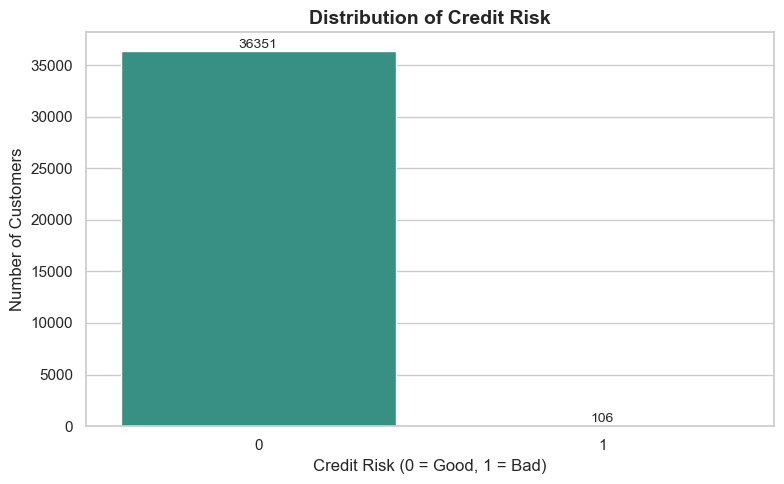

CREDIT_RISK
0    36351
1      106
Name: count, dtype: int64


In [31]:
plt.figure(figsize=(8, 5))

ax = sb.countplot(
    data=df,
    x='CREDIT_RISK',
    hue='CREDIT_RISK',
    palette=eda_palette,
    legend=False
)

plt.title('Distribution of Credit Risk', fontsize=14, fontweight='bold')
plt.xlabel('Credit Risk (0 = Good, 1 = Bad)')
plt.ylabel('Number of Customers')

for container in ax.containers:
    ax.bar_label(container, fontsize=10)

plt.tight_layout()
plt.show()
print(df.CREDIT_RISK.value_counts())

* #### The dataset contains 36,351 customers (99.71%) classified as Good Credit Risk, compared with only 106 customers (0.29%) classified as Bad Credit Risk.
* #### This indicates a severe class imbalance, with the good-risk category overwhelmingly dominating the dataset.

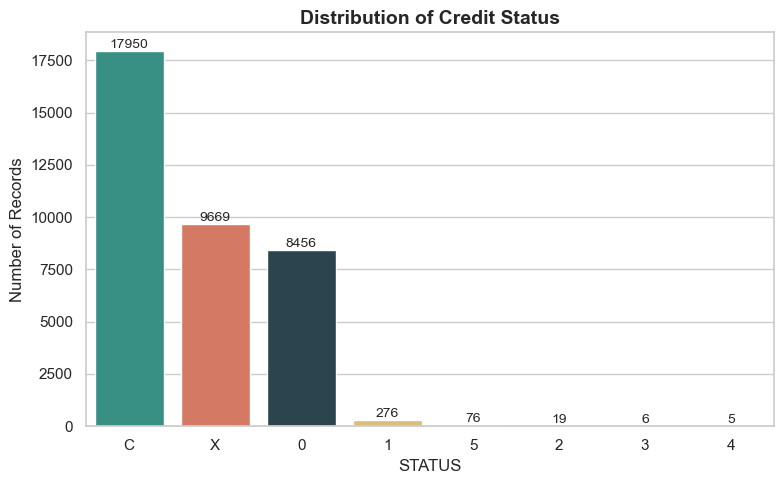

STATUS
C    17950
X     9669
0     8456
1      276
5       76
2       19
3        6
4        5
Name: count, dtype: int64


In [32]:
plt.figure(figsize=(8, 5))

status_order = df['STATUS'].value_counts().index

ax = sb.countplot(
    data=df,
    x='STATUS',
    hue='STATUS',
    order=status_order,
    palette=eda_palette,
    legend=False
)

plt.title('Distribution of Credit Status', fontsize=14, fontweight='bold')
plt.xlabel('STATUS')
plt.ylabel('Number of Records')

for container in ax.containers:
    ax.bar_label(container, fontsize=10)

plt.tight_layout()
plt.show()
print(df['STATUS'].value_counts())

### This bar chart shows the distribution of records across different Credit Status categories.

* #### Status C has the highest number of records with 17,950, making it the dominant category.
* #### Status X has 9,669 records, followed by Status 0 with 8,456 records.
* #### The remaining categories (1, 5, 2, 3, and 4) have very few observations compared with the major categories.
* #### This indicates a highly imbalanced categorical variable, where most records belong to C, X, or 0.

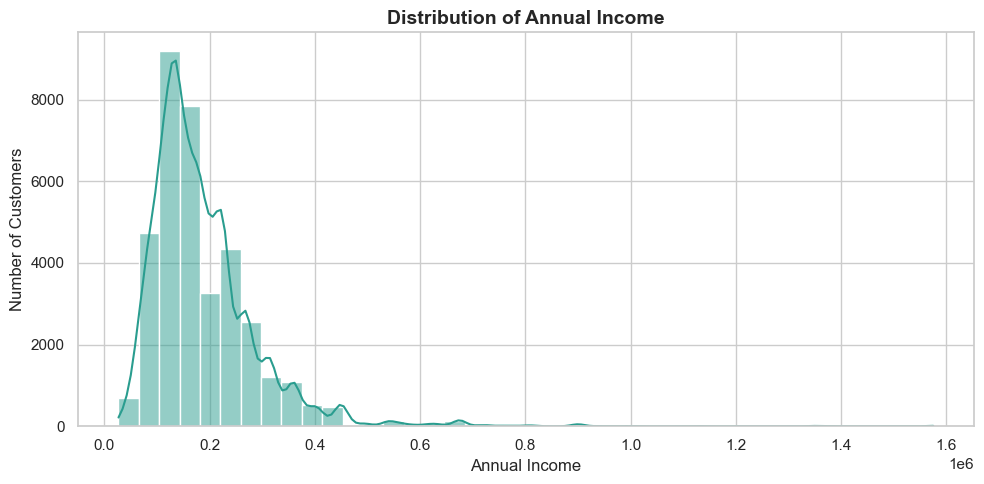

In [33]:
plt.figure(figsize=(10, 5))

sb.histplot(
    data=df,
    x='AMT_INCOME_TOTAL',
    bins=40,
    kde=True,
    color='#2A9D8F'
)

plt.title('Distribution of Annual Income', fontsize=14, fontweight='bold')
plt.xlabel('Annual Income')
plt.ylabel('Number of Customers')

plt.tight_layout()
plt.show()

* #### Annual income is highly right-skewed, with the majority of customers concentrated in the ₹100K–₹300K range.
* #### The highest concentration occurs around ₹120K–₹180K, where the number of customers reaches approximately 8,000–9,000.
* #### Customer frequency declines steadily as income increases beyond ₹300K, with relatively few customers having income above ₹500K, A long right tail extends up to approximately ₹1.6 million, indicating the presence of a small number of high-income customers/outliers.

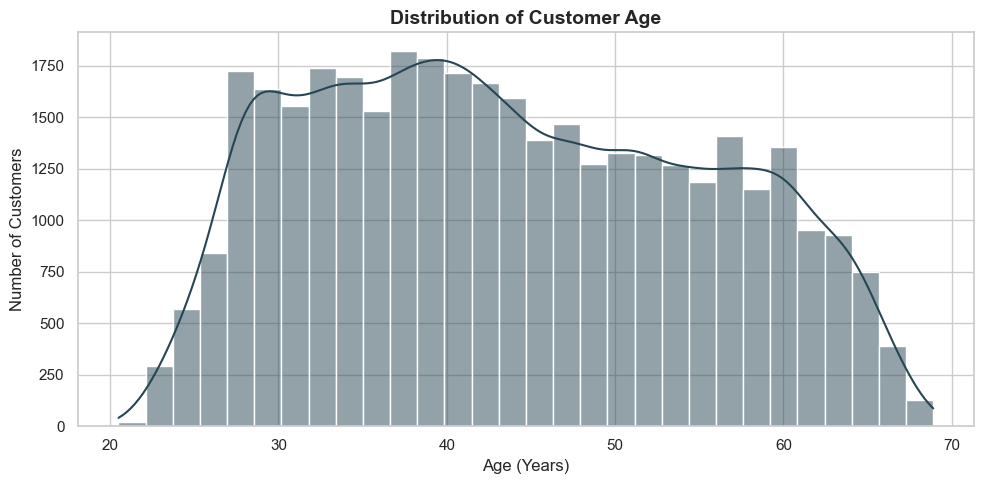

In [34]:
plt.figure(figsize=(10, 5))

sb.histplot(
    data=df,
    x='AGE',
    bins=30,
    kde=True,
    color='#264653'
)

plt.title('Distribution of Customer Age', fontsize=14, fontweight='bold')
plt.xlabel('Age (Years)')
plt.ylabel('Number of Customers')

plt.tight_layout()
plt.show()

* #### Customer ages are concentrated mainly between 28 and 60 years, with the highest representation around 35–40 years.
* #### The distribution is relatively broad, covering approximately 20 to 70 years, indicating a diverse customer age base.
* #### Customer counts gradually decline after around 40 years, with a more noticeable decrease beyond 60 years.

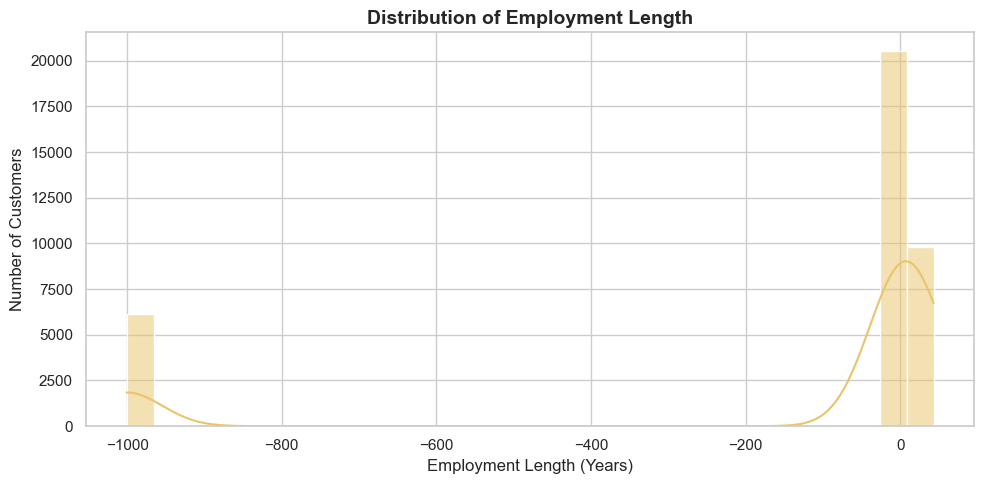

In [35]:
plt.figure(figsize=(10, 5))

sb.histplot(
    data=df,
    x='EMPLOYMENT_YEARS',
    bins=30,
    kde=True,
    color='#E9C46A'
)

plt.title('Distribution of Employment Length', fontsize=14, fontweight='bold')
plt.xlabel('Employment Length (Years)')
plt.ylabel('Number of Customers')

plt.tight_layout()
plt.show()

* #### The distribution is highly concentrated around 0–50 years, with the largest group containing approximately 20,000 customers, indicating that most recorded employment lengths fall within this range.
* #### A second notable group appears around -1,000 years, containing roughly 6,000 customers, which is not a realistic employment duration.

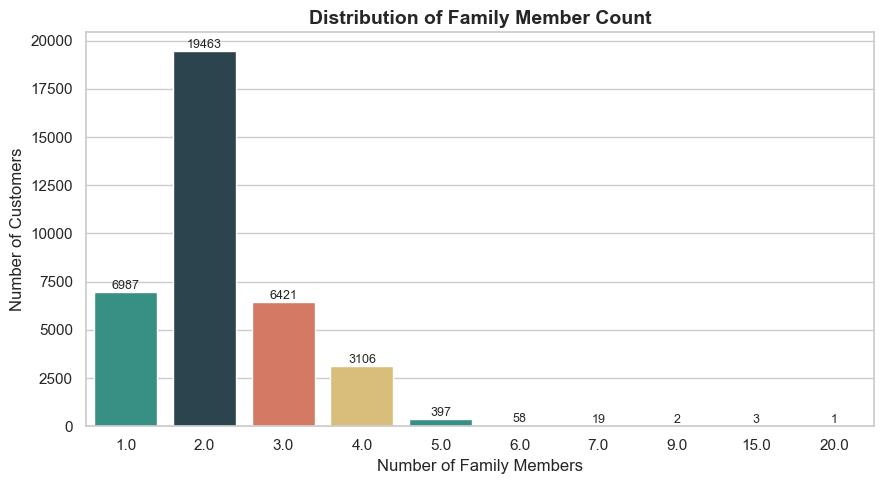

CNT_FAM_MEMBERS
2.0     19463
1.0      6987
3.0      6421
4.0      3106
5.0       397
6.0        58
7.0        19
15.0        3
9.0         2
20.0        1
Name: count, dtype: int64


In [36]:
plt.figure(figsize=(9, 5))

family_order = sorted(df['CNT_FAM_MEMBERS'].dropna().unique())

ax = sb.countplot(
    data=df,
    x='CNT_FAM_MEMBERS',
    hue='CNT_FAM_MEMBERS',
    order=family_order,
    palette=eda_palette,
    legend=False
)

plt.title('Distribution of Family Member Count', fontsize=14, fontweight='bold')
plt.xlabel('Number of Family Members')
plt.ylabel('Number of Customers')

for container in ax.containers:
    ax.bar_label(container, fontsize=9)

plt.tight_layout()
plt.show()
print(df.CNT_FAM_MEMBERS.value_counts())

* #### The majority of customers have 2 family members, with 19,463 customers (≈53.4%), making it the most common family size in the dataset. Customers with 1 family member account for 6,987 (≈19.2%), while 3 family members account for 6,421 (≈17.6%).
* #### The frequency decreases substantially for larger family sizes, with 4 members representing 3,106 customers (≈8.5%) and 5 members only 397 customers (≈1.1%).
* #### Family sizes above 5 members are very rare, with each category contributing less than 0.2% individually, indicating that the dataset is strongly concentrated around 1–3 family members.

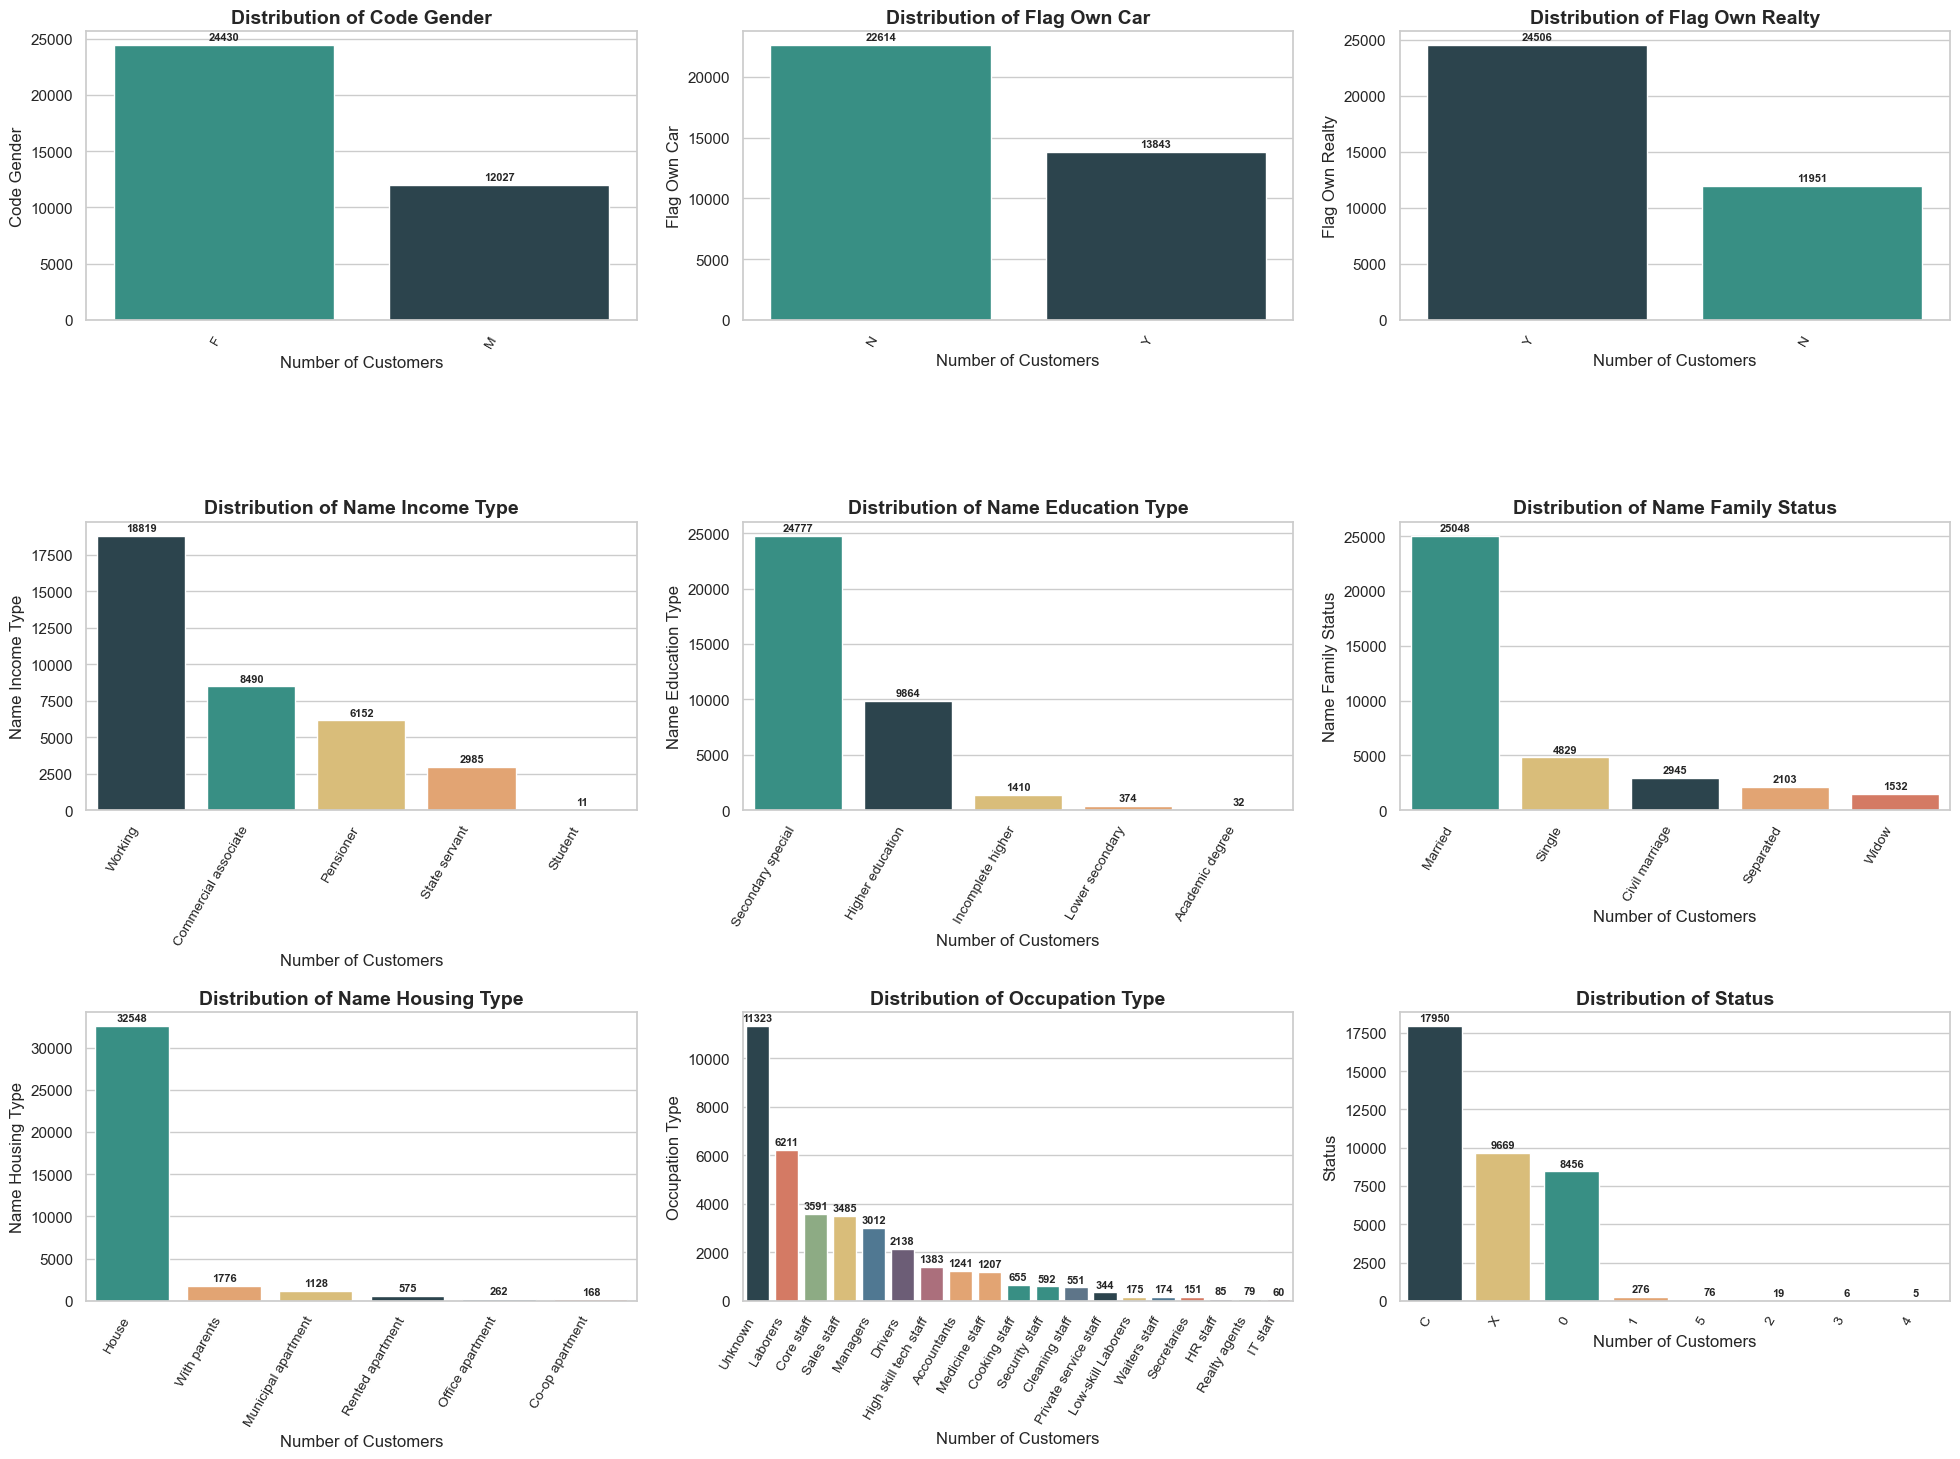

In [37]:
categorical_features = [
    'CODE_GENDER',
    'FLAG_OWN_CAR',
    'FLAG_OWN_REALTY',
    'NAME_INCOME_TYPE',
    'NAME_EDUCATION_TYPE',
    'NAME_FAMILY_STATUS',
    'NAME_HOUSING_TYPE',
    'OCCUPATION_TYPE',
    'STATUS'
]
category_palette = [
    '#264653',
    '#2A9D8F',
    '#E9C46A',
    '#F4A261',
    '#E76F51',
    '#457B9D',
    '#6D597A',
    '#8AB17D',
    '#B56576',
    '#577590'
]

plt.figure(figsize=(20, 15))
for i, feature in enumerate(categorical_features):
    plt.subplot(3, 3, i + 1) 

    order = df[feature].value_counts().index

    ax = sb.countplot(
        data=df,
        x=feature,
        hue=feature,
        order=order,
        palette=category_palette,
        legend=False
    )

    plt.title(
        f'Distribution of {feature.replace("_", " ").title()}',
        fontsize=14,
        fontweight='bold'
    )
    plt.xlabel('Number of Customers')
    plt.ylabel(feature.replace("_", " ").title())
    plt.xticks(rotation=60,ha='right',fontsize=10)

    for container in ax.containers:
        ax.bar_label(container, fontsize=8,fontweight='bold', padding=2)

plt.tight_layout(pad=1.8)
plt.subplots_adjust(hspace=0.7)
plt.show()

* #### Female customers dominate the dataset with 24,430 (67.0%), while males account for 12,027 (33.0%), Around 62.0% (22,614) of customers own a car, compared with 38.0% (13,843) who do not.
* #### Realty Ownership have 24,506 customers (67.2%) own real estate, while 11,951 (32.8%) do not, Working customers (18,819; 51.6%) form the largest group, followed by commercial associates and pensioners.
* #### Secondary education (24,777; 68.0%) is the dominant education level, followed by higher education at 27.1%, Married customers represent the majority with 25,048 (68.7%), while single customers account for 13.2%.
* #### House/apartment ownership is highly dominant, with 32,548 customers (89.3%), indicating limited variation in housing categories.
* #### Unknown occupation (11,323; 31.1%) is the largest category, followed by Laborers (6,211; 17.0%) and Core Staff (9.8%).
* #### Status C has the highest representation with 17,950 (49.2%), followed by X (26.5%) and O (23.2%), These imbalances should be considered during feature analysis and model development, particularly for categorical variables with rare groups.

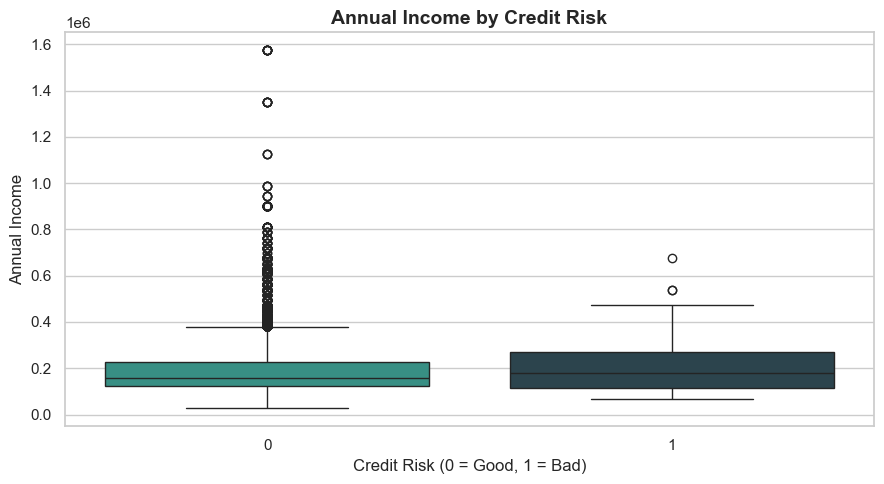

In [38]:
plt.figure(figsize=(9, 5))

ax = sb.boxplot(
    data=df,
    x='CREDIT_RISK',
    y='AMT_INCOME_TOTAL',
    hue='CREDIT_RISK',
    palette=eda_palette,
    legend=False
)

plt.title('Annual Income by Credit Risk', fontsize=14, fontweight='bold')
plt.xlabel('Credit Risk (0 = Good, 1 = Bad)')
plt.ylabel('Annual Income')

plt.tight_layout()
plt.show()

* #### The boxplot compares annual income (AMT_INCOME_TOTAL) across good (0) and bad (1) credit-risk groups, Both groups show a wide spread in annual income, indicating substantial income variation among customers.
* #### The distributions contain high-income outliers, suggesting that a small number of customers earn significantly more than the majority.

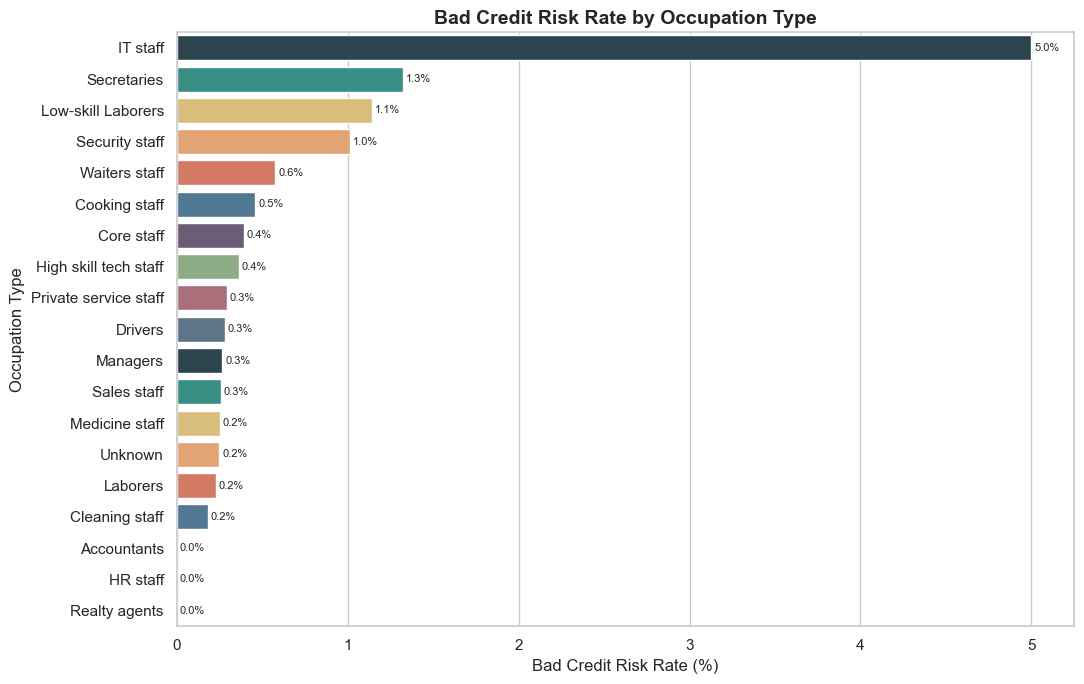

,OCCUPATION_TYPE,mean,count,Bad_Risk_Rate
7,IT staff,0.050000,60,5.000000
15,Secretaries,0.013245,151,1.324503
9,Low-skill Laborers,0.011429,175,1.142857
16,Security staff,0.010135,592,1.013514
18,Waiters staff,0.005747,174,0.574713
2,Cooking staff,0.004580,655,0.458015
3,Core staff,0.003899,3591,0.389864
6,High skill tech staff,0.003615,1383,0.361533
12,Private service staff,0.002907,344,0.290698
4,Drivers,0.002806,2138,0.280636


In [39]:
occupation_risk = (
    df.groupby('OCCUPATION_TYPE')['CREDIT_RISK']
      .agg(['mean', 'count'])
      .reset_index()
)

occupation_risk['Bad_Risk_Rate'] = occupation_risk['mean'] * 100
occupation_risk = occupation_risk.sort_values(
    'Bad_Risk_Rate',
    ascending=False
)

plt.figure(figsize=(11, 7))

ax = sb.barplot(
    data=occupation_risk,
    y='OCCUPATION_TYPE',
    x='Bad_Risk_Rate',
    hue='OCCUPATION_TYPE',
    order=occupation_risk['OCCUPATION_TYPE'],
    palette=category_palette,
    legend=False
)

plt.title(
    'Bad Credit Risk Rate by Occupation Type',
    fontsize=14,
    fontweight='bold'
)
plt.xlabel('Bad Credit Risk Rate (%)')
plt.ylabel('Occupation Type')

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.1f%%',
        fontsize=8,
        padding=2
    )

plt.tight_layout()
plt.show()
occupation_risk

* #### IT staff have the highest bad credit risk rate at 5.0%, substantially higher than all other occupations. Secretaries (1.3%), Low-skill Laborers (1.1%), and Security staff (1.0%) follow with comparatively higher risk rates.
* #### Most remaining occupations have bad credit risk rates below 1%, with several categories around 0.2–0.4%.
* #### Accountants, HR staff, and Realty agents show approximately 0% bad credit risk in this dataset.
* #### Overall, the chart indicates considerable variation in bad credit risk across occupations, although some categories may have small sample sizes and should be interpreted cautiously.

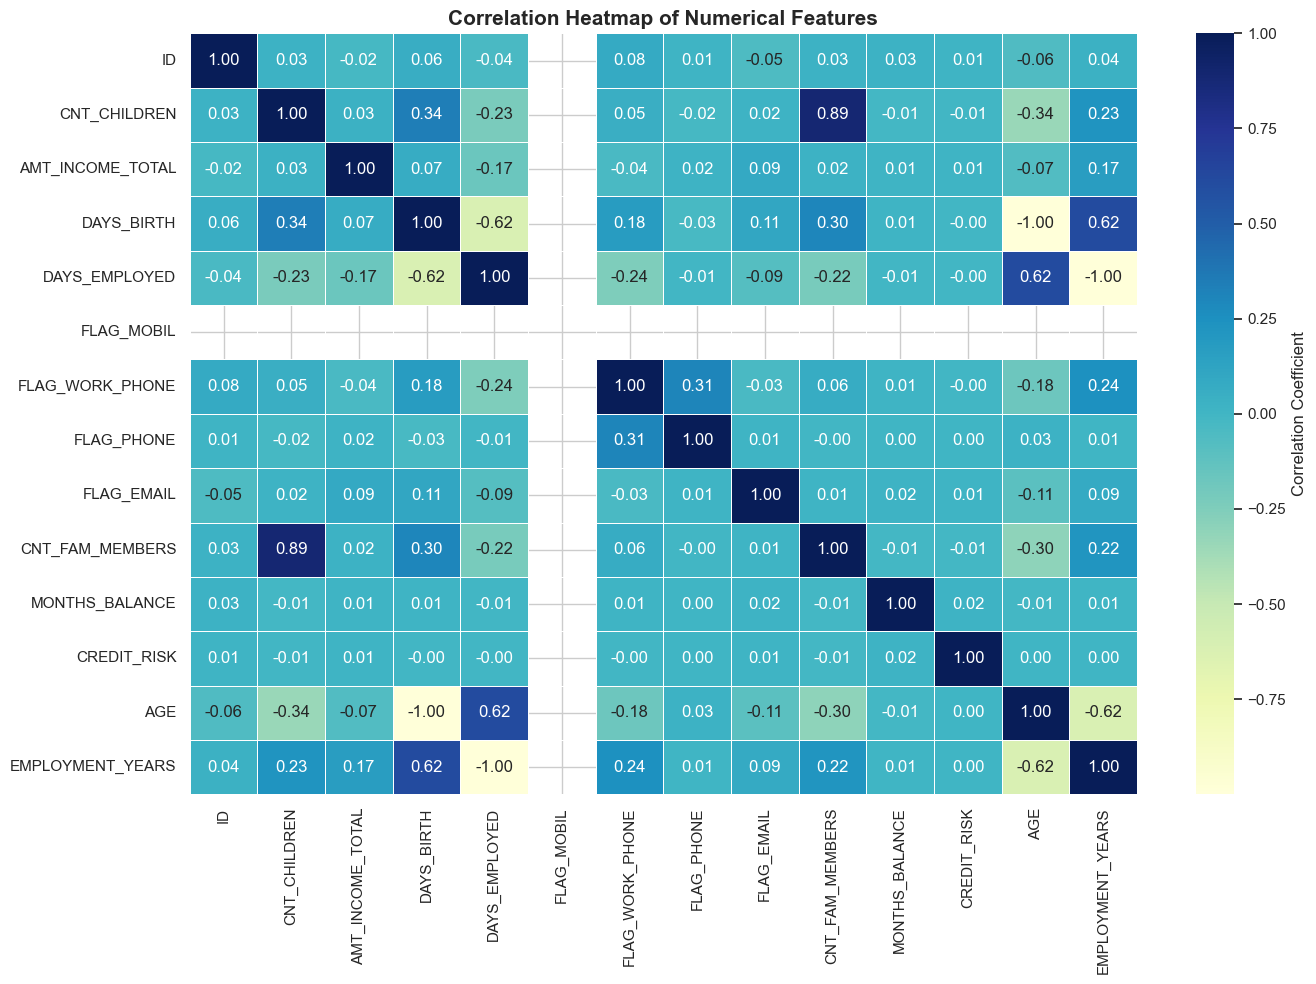

In [40]:
numerical_features = df.select_dtypes(include='number').columns
correlation_matrix = df[numerical_features].corr()

plt.figure(figsize=(14, 10))
sb.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='YlGnBu',
    linewidths=0.5,
    cbar_kws={'label': 'Correlation Coefficient'}
)

plt.title(
    'Correlation Heatmap of Numerical Features',
    fontsize=15,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

* #### CNT_FAM_MEMBERS and CNT_CHILDREN show a strong positive correlation of 0.89, indicating that customers with more children generally have larger family sizes.
* #### DAYS_BIRTH and DAYS_EMPLOYED have a strong negative correlation of -0.62, while AGE and EMPLOYMENT_YEARS show a similar relationship of -0.62 due to the underlying time-based variables.
* #### AGE and DAYS_BIRTH have an almost perfect negative correlation of -1.00, indicating these variables represent essentially the same age information in different forms.
* #### DAYS_EMPLOYED and EMPLOYMENT_YEARS also have a perfect negative correlation of -1.00, suggesting they are redundant representations of employment duration.
* #### CREDIT_RISK has correlations close to zero with the numerical features, indicating no strong linear relationship between credit risk and these individual numerical variables.

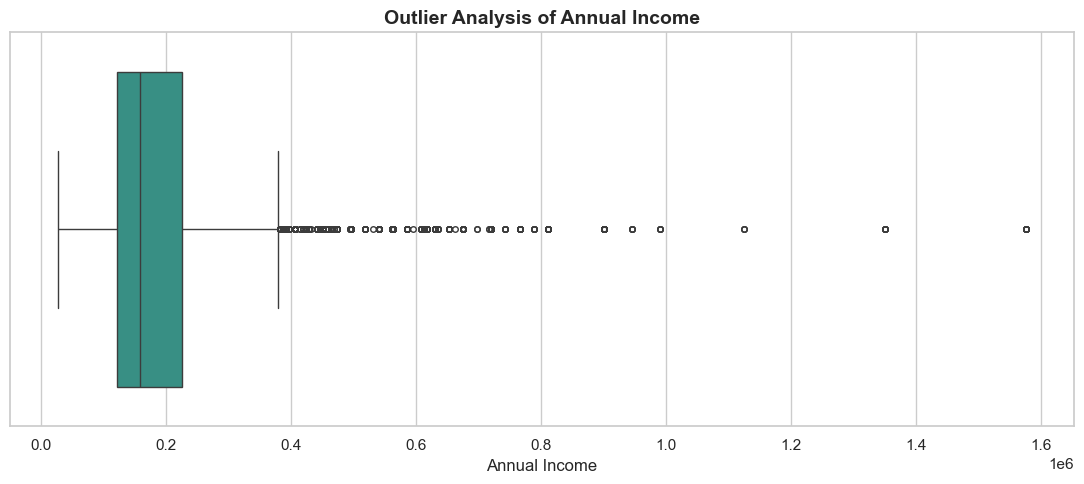

Number of income outliers: 1,529
Lower bound: -33,750.00
Upper bound: 380,250.00


In [41]:
plt.figure(figsize=(11, 5))

sb.boxplot(
    data=df,
    x='AMT_INCOME_TOTAL',
    color='#2A9D8F',
    fliersize=4
)

plt.title(
    'Outlier Analysis of Annual Income',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Annual Income')

plt.tight_layout()
plt.show()

Q1 = df['AMT_INCOME_TOTAL'].quantile(0.25)
Q3 = df['AMT_INCOME_TOTAL'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
income_outliers = df[
    (df['AMT_INCOME_TOTAL'] < lower_bound) |
    (df['AMT_INCOME_TOTAL'] > upper_bound)
]

print(f"Number of income outliers: {len(income_outliers):,}")
print(f"Lower bound: {lower_bound:,.2f}")
print(f"Upper bound: {upper_bound:,.2f}")

* #### The boxplot shows that annual income is strongly right-skewed, with most customers concentrated in the lower-to-middle income range.
* #### The median income is around 0.16 million, while the central 50% of customers fall approximately between 0.12 and 0.23 million.
* #### Several high-income outliers are visible beyond the upper whisker, extending from roughly 0.4 million to 1.6 million.

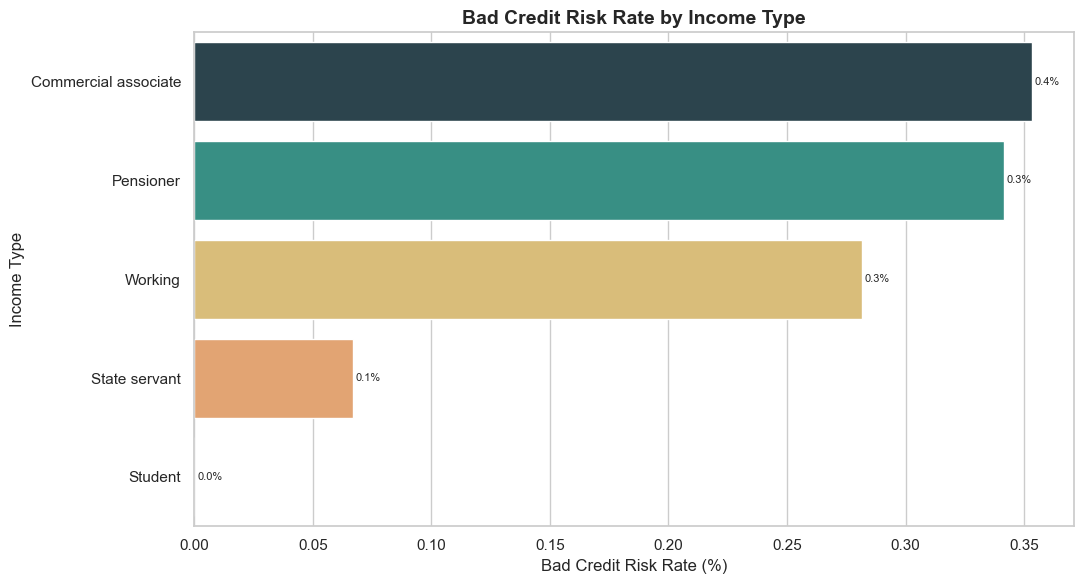

       NAME_INCOME_TYPE      mean  count  Bad_Risk_Rate
0  Commercial associate  0.003534   8490       0.353357
1             Pensioner  0.003414   6152       0.341352
4               Working  0.002816  18819       0.281630
2         State servant  0.000670   2985       0.067002
3               Student  0.000000     11       0.000000


In [42]:
income_type_risk = (
    df.groupby('NAME_INCOME_TYPE')['CREDIT_RISK']
      .agg(['mean', 'count'])
      .reset_index()
)

income_type_risk['Bad_Risk_Rate'] = income_type_risk['mean'] * 100
income_type_risk = income_type_risk.sort_values(
    'Bad_Risk_Rate',
    ascending=False
)

plt.figure(figsize=(11, 6))

ax = sb.barplot(
    data=income_type_risk,
    y='NAME_INCOME_TYPE',
    x='Bad_Risk_Rate',
    hue='NAME_INCOME_TYPE',
    order=income_type_risk['NAME_INCOME_TYPE'],
    palette=category_palette,
    legend=False
)

plt.title(
    'Bad Credit Risk Rate by Income Type',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Bad Credit Risk Rate (%)')
plt.ylabel('Income Type')

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.1f%%',
        fontsize=8,
        padding=2
    )

plt.tight_layout()
plt.show()
print(income_type_risk)

* #### Commercial associates have the highest bad credit risk rate at 0.4%, followed by pensioners and working customers at 0.3% each. State servants show a comparatively lower bad credit risk rate of 0.1%.
* #### Students have an approximately 0.0% bad credit risk rate in the dataset. Overall, the differences across income types are relatively small, suggesting that income type alone may have limited ability to distinguish bad credit risk.

# Machinne Learning Model Selection

In [43]:
df.corr(numeric_only=True)

,ID,CNT_CHILDREN,AMT_INCOME_TOTAL,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,MONTHS_BALANCE,CREDIT_RISK,AGE,EMPLOYMENT_YEARS
ID,1.000000,0.028878,-0.017667,0.056016,-0.038043,NaN,0.079215,0.009879,-0.046979,0.026624,0.025194,0.013473,-0.056026,0.038042
CNT_CHILDREN,0.028878,1.000000,0.033691,0.339357,-0.229379,NaN,0.048091,-0.016291,0.015960,0.889114,-0.011469,-0.007283,-0.339343,0.229379
AMT_INCOME_TOTAL,-0.017667,0.033691,1.000000,0.067908,-0.168611,NaN,-0.037746,0.017245,0.086681,0.023750,0.008727,0.009432,-0.067911,0.168613
DAYS_BIRTH,0.056016,0.339357,0.067908,1.000000,-0.616213,NaN,0.179054,-0.028659,0.105625,0.304020,0.011395,-0.002825,-0.999997,0.616213
DAYS_EMPLOYED,-0.038043,-0.229379,-0.168611,-0.616213,1.000000,NaN,-0.242869,-0.007233,-0.085648,-0.221241,-0.006820,-0.002344,0.616222,-1.000000
FLAG_MOBIL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FLAG_WORK_PHONE,0.079215,0.048091,-0.037746,0.179054,-0.242869,NaN,1.000000,0.311644,-0.034838,0.064527,0.014203,-0.004761,-0.179058,0.242870
FLAG_PHONE,0.009879,-0.016291,0.017245,-0.028659,-0.007233,NaN,0.311644,1.000000,0.010455,-0.004221,0.003714,0.004190,0.028671,0.007234
FLAG_EMAIL,-0.046979,0.015960,0.086681,0.105625,-0.085648,NaN,-0.034838,0.010455,1.000000,0.014619,0.017209,0.013351,-0.105635,0.085648
CNT_FAM_MEMBERS,0.026624,0.889114,0.023750,0.304020,-0.221241,NaN,0.064527,-0.004221,0.014619,1.000000,-0.009034,-0.007843,-0.304024,0.221241


In [44]:
df.dtypes

ID                       int64
CODE_GENDER             object
FLAG_OWN_CAR            object
FLAG_OWN_REALTY         object
CNT_CHILDREN             int64
AMT_INCOME_TOTAL       float64
NAME_INCOME_TYPE        object
NAME_EDUCATION_TYPE     object
NAME_FAMILY_STATUS      object
NAME_HOUSING_TYPE       object
DAYS_BIRTH               int64
DAYS_EMPLOYED            int64
FLAG_MOBIL               int64
FLAG_WORK_PHONE          int64
FLAG_PHONE               int64
FLAG_EMAIL               int64
OCCUPATION_TYPE         object
CNT_FAM_MEMBERS        float64
MONTHS_BALANCE           int64
STATUS                  object
CREDIT_RISK              int64
AGE                    float64
EMPLOYMENT_YEARS       float64
dtype: object

## Converting Categorical Data into Numeric for Model Tuning

In [45]:
from sklearn.preprocessing import LabelEncoder
label = LabelEncoder()
df.FLAG_OWN_CAR=label.fit_transform(df.FLAG_OWN_CAR)
df.FLAG_OWN_REALTY=label.fit_transform(df.FLAG_OWN_REALTY)
df.AMT_INCOME_TOTAL=label.fit_transform(df.AMT_INCOME_TOTAL)
df.NAME_INCOME_TYPE=label.fit_transform(df.NAME_INCOME_TYPE)
df.NAME_EDUCATION_TYPE=label.fit_transform(df.NAME_EDUCATION_TYPE)
df.NAME_FAMILY_STATUS=label.fit_transform(df.NAME_FAMILY_STATUS)
df.NAME_HOUSING_TYPE=label.fit_transform(df.NAME_HOUSING_TYPE)
df.DAYS_EMPLOYED=label.fit_transform(df.DAYS_EMPLOYED)
df.OCCUPATION_TYPE=label.fit_transform(df.OCCUPATION_TYPE)
df.CNT_FAM_MEMBERS=label.fit_transform(df.CNT_FAM_MEMBERS)
df.MONTHS_BALANCE=label.fit_transform(df.MONTHS_BALANCE)

# Define Prediction Target & Features
* ### Target variable:- [y]  Features:- [x]

In [46]:
y = df['CREDIT_RISK']

feature_columns = [
    'FLAG_OWN_CAR',
    'FLAG_OWN_REALTY',
    'AMT_INCOME_TOTAL',
    'NAME_INCOME_TYPE',
    'NAME_EDUCATION_TYPE',
    'NAME_FAMILY_STATUS',
    'NAME_HOUSING_TYPE',
    'DAYS_EMPLOYED',
    'OCCUPATION_TYPE',
    'CNT_FAM_MEMBERS',
    'MONTHS_BALANCE'
]
x = df[feature_columns]

print("Features shape:", x.shape)
print("Target shape:", y.shape)

print("\nSelected Features:")
print(x.columns.tolist())

print("\nTarget Distribution:")
print(y.value_counts())

Features shape: (36457, 11)
Target shape: (36457,)

Selected Features:
['FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'AMT_INCOME_TOTAL', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'DAYS_EMPLOYED', 'OCCUPATION_TYPE', 'CNT_FAM_MEMBERS', 'MONTHS_BALANCE']

Target Distribution:
CREDIT_RISK
0    36351
1      106
Name: count, dtype: int64


In [47]:
display(x.head())

print("\nFeature Data Types:")
display(x.dtypes)

print("\nTarget Values:")
print(y.unique())

,FLAG_OWN_CAR,FLAG_OWN_REALTY,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_EMPLOYED,OCCUPATION_TYPE,CNT_FAM_MEMBERS,MONTHS_BALANCE
0,1,1,226,4,1,0,4,1005,17,1,60
1,1,1,226,4,1,0,4,1005,17,1,60
2,1,1,77,4,4,1,1,2845,16,1,60
3,0,1,192,0,4,3,1,1631,14,0,60
4,0,1,192,0,4,3,1,1631,14,0,38



Feature Data Types:


FLAG_OWN_CAR           int64
FLAG_OWN_REALTY        int64
AMT_INCOME_TOTAL       int64
NAME_INCOME_TYPE       int64
NAME_EDUCATION_TYPE    int64
NAME_FAMILY_STATUS     int64
NAME_HOUSING_TYPE      int64
DAYS_EMPLOYED          int64
OCCUPATION_TYPE        int64
CNT_FAM_MEMBERS        int64
MONTHS_BALANCE         int64
dtype: object


Target Values:
[0 1]


### Split data in train & test sets

In [73]:
from sklearn.model_selection import train_test_split
xtrain,xtest,ytrain,ytest= train_test_split(x,y,test_size=0.2)

### Train ML Models & Evaluation metrics selection

# Logistic Regression

In [90]:
from sklearn.linear_model import LogisticRegression
modellogistic= LogisticRegression()
modellogistic.fit(xtrain,ytrain)
yplogistic= modellogistic.predict(xtest)
modellogistic

LogisticRegression()

In [91]:
from sklearn.metrics import accuracy_score,confusion_matrix,f1_score
acc = accuracy_score(ytest,yplogistic)
cm = confusion_matrix(ytest,yplogistic)
f = f1_score(ytest, yplogistic)
print("confusion_matrix :\n", cm)
print("Accuracy Score:", acc*100)
print("F1 Score:", f*100)

confusion_matrix :
 [[7265    0]
 [  27    0]]
Accuracy Score: 99.62973121228744
F1 Score: 0.0


In [92]:
from sklearn.model_selection import cross_val_score
cvlogistic = LogisticRegression()
logistic_cvscore = cross_val_score(cvlogistic,x,y,cv=15,scoring='accuracy')
print(logistic_cvscore)
print('logistic_cvscore',logistic_cvscore.mean()*100)

[0.99712053 0.99712053 0.99712053 0.99712053 0.99712053 0.99712053
 0.99670917 0.99711934 0.99711934 0.99711934 0.99711934 0.99711934
 0.99711934 0.99711934 0.99711934]
logistic_cvscore 99.70924709922534


# Random Forest Classification

In [77]:
from sklearn.ensemble import RandomForestClassifier
modelR=RandomForestClassifier(class_weight='balanced')
modelR.fit(xtrain,ytrain)
ypr=modelR.predict(xtest)
modelR

RandomForestClassifier(class_weight='balanced')

In [78]:
cm1 = confusion_matrix(ytest,ypr)
acc1 = accuracy_score(ytest,ypr)
f1 = f1_score(ytest, ypr)
print("confusion_matrix :\n", cm1)
print("Accuracy Score:", acc1*100)
print("F1 Score:", f1*100)

confusion_matrix :
 [[7235   30]
 [  15   12]]
Accuracy Score: 99.3828853538124
F1 Score: 34.78260869565217


In [71]:
cvR = RandomForestClassifier()
rcv_score = cross_val_score(cvR,x,y,cv=15,scoring='accuracy')
print(rcv_score)
print('RandomForest_cvscore',rcv_score.mean()*100)

[0.9938297  0.99712053 0.99670917 0.99341835 0.99670917 0.9938297
 0.99506376 0.99465021 0.99711934 0.99670782 0.98765432 0.99382716
 0.99382716 0.99547325 0.99382716]
RandomForest_cvscore 99.46511198798781


### Hyperparameter Tuning of Random Forest Classifier using Grid Search CV

In [101]:
from sklearn.model_selection import GridSearchCV
tuned_parameters = {'n_estimators': [50, 100, 200, 300, 500]}
model_gscv = RandomForestClassifier(random_state=42)
new_model = GridSearchCV(estimator=model_gscv,param_grid=tuned_parameters,scoring='accuracy',cv=15)
new_model

GridSearchCV(cv=15, estimator=RandomForestClassifier(random_state=42),
             param_grid={'n_estimators': [50, 100, 200, 300, 500]},
             scoring='accuracy')

In [103]:
new_model.fit(xtrain, ytrain)

GridSearchCV(cv=15, estimator=RandomForestClassifier(random_state=42),
             param_grid={'n_estimators': [50, 100, 200, 300, 500]},
             scoring='accuracy')

In [104]:
print("Best Parameter:", new_model.best_params_)
print("Best Accuracy Score:", new_model.best_score_*100)

Best Parameter: {'n_estimators': 100}
Best Accuracy Score: 99.6948420380773


# XG Boost Classification

In [79]:
from xgboost import XGBClassifier
modelxgc= XGBClassifier(scale_pos_weight=303)
modelxgc.fit(xtrain,ytrain)
ypxgc= modelxgc.predict(xtest)
modelxgc

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [80]:
cm2 = confusion_matrix(ytest,ypxgc)
acc2 = accuracy_score(ytest,ypxgc)
f2 = f1_score(ytest, ypxgc)
print("confusion_matrix :\n", cm2)
print("Accuracy Score:", acc2*100)
print("F1 Score:", f2*100)

confusion_matrix :
 [[7199   66]
 [  14   13]]
Accuracy Score: 98.90290729566648
F1 Score: 24.528301886792452


In [81]:
cvxgc = XGBClassifier()
xgcv = cross_val_score(cvxgc,x,y,cv=15,scoring='accuracy')
print(xgcv)
print('XGBoost_cvscore',xgcv.mean()*100)

[0.99547511 0.99712053 0.99670917 0.99506376 0.99712053 0.99424105
 0.99465241 0.99465021 0.99711934 0.99711934 0.99012346 0.99465021
 0.99670782 0.99588477 0.99670782]
XGBoost_cvscore 99.55563681053877


## Compare Each Models Evaluation 

In [93]:
results = pd.DataFrame({
    "Model": ['LogisticRegression','RandomForestClassifier','XGBClassifier'],
    "Accuracy Score": [acc*100, acc1*100, acc2*100],
    "Cross_Validation_Score": [logistic_cvscore.mean()*100,rcv_score.mean()*100,xgcv.mean()*100],
    "F1 Score": [f*100,f1*100,f2*100]
})

results = results.sort_values(by=["Accuracy Score", "Cross_Validation_Score",'F1 Score'], ascending=[False,False,True]).reset_index(drop=True)

print(results)

                    Model  Accuracy Score  Cross_Validation_Score   F1 Score
0      LogisticRegression       99.629731               99.709247   0.000000
1  RandomForestClassifier       99.382885               99.465112  34.782609
2           XGBClassifier       98.902907               99.555637  24.528302


* #### Logistic Regression achieves the highest accuracy (99.63%) and cross-validation score (99.71%), However, its F1 Score is 0%, indicating that it fails to effectively identify the minority class.
* #### Random Forest achieves 99.38% accuracy with the highest F1 Score of 34.78% among the three models.
* #### XGBoost records 98.90% accuracy and a strong cross-validation score of 99.56% and an F1 Score of approximately 24.53%.
* #### The high accuracy across all models is influenced by the class imbalance in the dataset.